<a target="_blank" href="https://colab.research.google.com/github/bmalcover/AppOC/blob/main/docs/notebooks/05_Text/03_Tokenization.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Tokenization

Tokenization is the process of splitting text into units that a language model can process. These units are called tokens, and they are not the same as words.

**Suggested duration:** 30 minutes

<div class="alert alert-warning">
<b>Learning goals</b>

By the end of this notebook, you should be able to:

- explain what tokenization is and why LLMs need it
- relate tokens to cost, context length, and latency
- distinguish common tokenization strategies at a high level
- inspect how different kinds of text are split into tokens
- recognize why tokenization affects multilingual and code-heavy workflows
</div>

<div class="alert alert-warning">
<b>Table of Contents</b>

1. [What is tokenization?](#what-is-tokenization)
2. [Why it matters](#why-it-matters)
3. [Common tokenization strategies](#common-tokenization-strategies)
4. [Tools and visualizations](#tools-and-visualizations)
5. [Mini demos](#mini-demos)
</div>

## What is tokenization? <a id="what-is-tokenization"></a>

LLMs do not read raw text directly. They convert text into tokens first.

A token may be:

- a full word
- part of a word
- punctuation
- whitespace patterns
- pieces of code

Because of this, 100 words is not always 100 tokens. English, Spanish, code, equations, and emoji can all tokenize differently.

## Why it matters <a id="why-it-matters"></a>

Tokenization matters because it affects:

- **cost**: many APIs charge per token
- **context window usage**: long inputs may exceed model limits
- **latency**: more tokens usually means slower responses
- **multilingual performance**: some languages break into more pieces
- **formatting quality**: code and tables can be token-heavy
- **a simple approach to solve**:classification and recommendations problems

## Common tokenization strategies <a id="common-tokenization-strategies"></a>

High-level families include:

- **word-based tokenization**: simple but poor for unseen words
- **subword tokenization**: breaks rare words into reusable pieces
- **byte-level tokenization**: robust across many scripts and symbols

Modern LLMs often rely on subword or byte-level approaches because they balance vocabulary size and coverage.

## Tools and visualizations <a id="tools-and-visualizations"></a>


- [https://projector.tensorflow.org/](https://projector.tensorflow.org/)
- [https://tokenization-visualization.netlify.app/](https://tokenization-visualization.netlify.app/)
- [HF Playground](https://huggingface.co/spaces/Xenova/the-tokenizer-playground)



In [2]:
from transformers import AutoTokenizer

text = "Ocean temperature anomalies in 2025 were higher than expected."

# Compare how several pretrained tokenizers split the same text.
model_names = [
    "bert-base-uncased",
    "roberta-base",
    "gpt2",
    "xlm-roberta-base",
]

print("Original text:", text)
print()

for model_name in model_names:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokens = tokenizer.tokenize(text)
    token_ids = tokenizer.convert_tokens_to_ids(tokens)

    print(f"Model: {model_name}")
    print("Tokens:", tokens)
    print("Token IDs:", token_ids)
    print("Count:", len(tokens))
    print("-" * 70)

/Users/isaac/Projects/AppOC/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Original text: Ocean temperature anomalies in 2025 were higher than expected.



Model: bert-base-uncased
Tokens: ['ocean', 'temperature', 'an', '##oma', '##lies', 'in', '202', '##5', 'were', 'higher', 'than', 'expected', '.']
Token IDs: [4153, 4860, 2019, 9626, 11983, 1999, 16798, 2629, 2020, 3020, 2084, 3517, 1012]
Count: 13
----------------------------------------------------------------------
Model: roberta-base
Tokens: ['Ocean', 'Ġtemperature', 'Ġanomalies', 'Ġin', 'Ġ2025', 'Ġwere', 'Ġhigher', 'Ġthan', 'Ġexpected', '.']
Token IDs: [41496, 5181, 36071, 11, 10380, 58, 723, 87, 421, 4]
Count: 10
----------------------------------------------------------------------
Model: gpt2
Tokens: ['Ocean', 'Ġtemperature', 'Ġanomalies', 'Ġin', 'Ġ2025', 'Ġwere', 'Ġhigher', 'Ġthan', 'Ġexpected', '.']
Token IDs: [46607, 5951, 35907, 287, 32190, 547, 2440, 621, 2938, 13]
Count: 10
----------------------------------------------------------------------
Model: xlm-roberta-base
Tokens: ['▁Ocean', '▁temperature', '▁anomali', 'es', '▁in', '▁2025', '▁were', '▁higher', '▁than', '▁expecte

## Demo <a id="mini-demos"></a>

First, with 3 and, after 4 sentences!


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18415.67it/s]


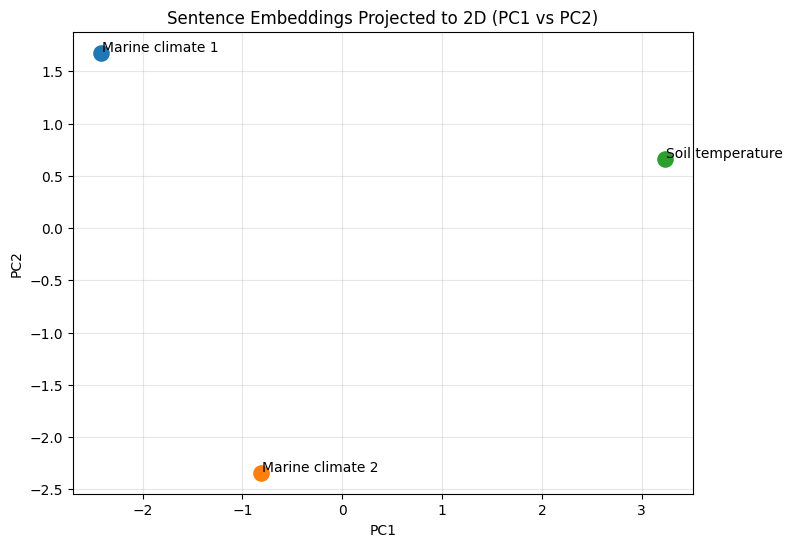

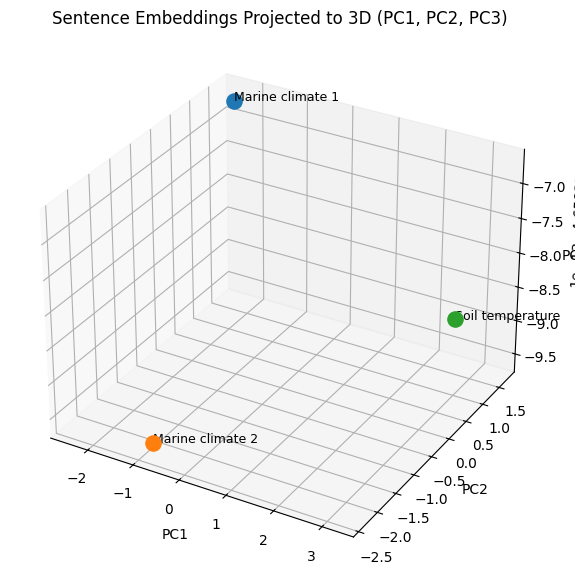

Explained variance ratio (PC1, PC2, PC3): [6.5944564e-01 3.4055436e-01 2.5364978e-14]


In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from transformers import AutoModel, AutoTokenizer

sentences = [
    "Marine climatology shows persistent warm sea-surface temperature anomalies in the eastern Atlantic.",
    "Ocean heat content and salinity gradients indicate a stronger upper-layer stratification this season.",
    "Soil temperature over inland agricultural areas rises faster during dry spells and low moisture conditions.",
    # "The use of chemicals in food industry is a global issue in health."
]
labels = [
    "Marine climate 1",
    "Marine climate 2",
    "Soil temperature",
    # "Chemicals in food"
]

model_name = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

encoded = tokenizer(sentences, padding=True, truncation=True, return_tensors="pt")
with __import__("torch").no_grad():
    outputs = model(**encoded)

# Mean pooling with attention mask to get one embedding per sentence.
attention_mask = encoded["attention_mask"].unsqueeze(-1)
masked = outputs.last_hidden_state * attention_mask
sentence_embeddings = masked.sum(dim=1) / attention_mask.sum(dim=1)
X = sentence_embeddings.detach().cpu().numpy()

# If embedding dim is high, reduce first to 3 principal components.
pca3 = PCA(n_components=3)
X3 = pca3.fit_transform(X)

# 2D projection (PC1 vs PC2)
plt.figure(figsize=(8, 6))
for i, label in enumerate(labels):
    plt.scatter(X3[i, 0], X3[i, 1], s=120)
    plt.text(X3[i, 0] + 0.01, X3[i, 1] + 0.01, label, fontsize=10)

plt.title("Sentence Embeddings Projected to 2D (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.3)
plt.show()

# 3D projection (PC1, PC2, PC3)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for i, label in enumerate(labels):
    ax.scatter(X3[i, 0], X3[i, 1], X3[i, 2], s=120)
    ax.text(X3[i, 0], X3[i, 1], X3[i, 2], label, fontsize=9)

ax.set_title("Sentence Embeddings Projected to 3D (PC1, PC2, PC3)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

print("Explained variance ratio (PC1, PC2, PC3):", pca3.explained_variance_ratio_)

<div class="alert alert-info">
<b>Activity</b> <a id="exercises"></a>
</div>

Do the same with the following terms:

In [ ]:


examples = [
    "chlorophyll",
    "Brandon Sanderson",
    "sea_surface_temperature",
    "flowers and plants in the field",
    "CO2",
    "The ways of kings",
    "Guerra de los Cien Años"
]

